In [ ]:
print("VoltRelay Energy Hackathon")
print("Data Analytics Project")

VoltRelay Energy Hackathon
Data Analytics Project


In [ ]:
import os

os.listdir("/content")

['.config', 'hackathon_data', 'sample_data']

In [ ]:
import glob

files = glob.glob("/drive-download-*")
print(files)

['/drive-download-20260926T031421Z-1-001.zip']


In [ ]:
import zipfile
import os

zip_path = "/drive-download-20260926T031421Z-1-001.zip"
extract_path = "/content/hackathon_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

data_path = "/content/hackathon_data"

files = os.listdir(data_path)

print("Files in dataset:")
for file in files:
    print(file)

Files in dataset:
fleet_partners.csv
support_tickets.csv
city_daily_context.csv
station_hourly_status.csv
stations.csv
batteries.csv
swap_events.csv
riders.csv


In [ ]:
import pandas as pd

stations_path = "/content/hackathon_data/stations.csv"

stations = pd.read_csv(stations_path)

stations.head()

,station_id,city,zone,latitude,longitude,location_type,host_type,commissioned_date,decommissioned_date,expansion_wave,...,slots_3w,inventory_target_2w,inventory_target_3w,monthly_rent_inr,monthly_maintenance_inr,grid_tariff_inr_kwh,connectivity_tier,firmware_version,firmware_updated_date,competitor_within_1_5km_since
0,STN-BLR-001,Bengaluru,BLR-Electronic City,12.926943,77.604655,transit_hub,mall_parking,2023-12-09,NaN,Launch,...,6,32,7,23247,5436,9.29,good,v3.2.1,2025-04-14,NaN
1,STN-BLR-002,Bengaluru,BLR-Central,13.149199,77.530565,commercial_hub,kirana,2023-06-20,NaN,Launch,...,0,38,0,23201,5249,8.41,poor,v3.2.1,2025-04-14,NaN
2,STN-BLR-003,Bengaluru,BLR-Electronic City,12.917986,77.607560,commercial_hub,fuel_retailer,2023-09-26,NaN,Launch,...,0,43,0,10281,4516,8.66,good,v3.2.1,2025-04-14,NaN
3,STN-BLR-004,Bengaluru,BLR-Whitefield,13.030901,77.489397,market,mall_parking,2023-08-25,NaN,Launch,...,0,33,0,12322,5802,9.19,good,v3.2.1,2025-04-14,NaN
4,STN-BLR-005,Bengaluru,BLR-North,12.815864,77.628712,residential,mall_parking,2023-11-07,NaN,Launch,...,0,15,0,24194,7134,8.68,fair,v3.2.1,2025-04-14,NaN


In [ ]:
stations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   station_id                     152 non-null    object 
 1   city                           152 non-null    object 
 2   zone                           152 non-null    object 
 3   latitude                       152 non-null    float64
 4   longitude                      152 non-null    float64
 5   location_type                  152 non-null    object 
 6   host_type                      152 non-null    object 
 7   commissioned_date              152 non-null    object 
 8   decommissioned_date            1 non-null      object 
 9   expansion_wave                 152 non-null    object 
 10  charger_generation             152 non-null    object 
 11  slots_2w                       152 non-null    int64  
 12  slots_3w                       152 non-null    int

In [ ]:
stations.isnull().sum()

,0
station_id,0
city,0
zone,0
latitude,0
longitude,0
location_type,0
host_type,0
commissioned_date,0
decommissioned_date,151
expansion_wave,0


In [ ]:
stations.duplicated().sum()

np.int64(0)

In [ ]:
stations["city"].value_counts()

,count
city,
Bengaluru,34
Delhi NCR,30
Hyderabad,26
Pune,22
Mumbai,22
Jaipur,18


In [ ]:
stations["location_type"].value_counts()

,count
location_type,
market,47
commercial_hub,46
highway_fuel_pump,21
residential,21
transit_hub,10
tech_park,7


In [ ]:
stations["charger_generation"].value_counts()

,count
charger_generation,
Gen2,64
Gen1,51
Gen3,37


In [ ]:
stations["connectivity_tier"].value_counts()

,count
connectivity_tier,
good,100
fair,29
poor,23


In [ ]:
swap_path = "/content/hackathon_data/swap_events.csv"

swaps = pd.read_csv(swap_path)

swaps.head()

,event_id,rider_id,station_id,event_ts,event_type,attempt_seq,queue_wait_sec,battery_in_id,battery_out_id,soc_in_pct,...,soh_out_pct,km_since_last_swap,tariff_code,list_price_inr,discount_inr,amount_charged_inr,payment_mode,energy_to_recharge_kwh,station_firmware,sync_mode
0,SW-000000001,RD-1000003,STN-MUM-115,2024-01-01 11:10:56,swap_completed,1,88,BAT-2W-103542,BAT-2W-102547,15.0,...,98.9,80.4,PARTNER,60.0,6.0,54.0,partner_invoice,2.035,v3.2.1,realtime
1,SW-000000002,RD-1000004,STN-HYD-070,2024-01-01 17:13:06,swap_completed,1,148,BAT-2W-105296,BAT-2W-101923,8.3,...,98.2,66.1,PARTNER,60.0,9.0,51.0,partner_invoice,2.157,v3.2.0,realtime
2,SW-000000003,RD-1000005,STN-DEL-046,2024-01-01 20:15:14,swap_completed,1,307,BAT-2W-104732,BAT-2W-102492,11.5,...,99.1,66.6,STD,60.0,0.0,60.0,partner_invoice,2.039,v3.2.0,realtime
3,SW-000000004,RD-1000006,STN-JAI-135,2024-01-01 20:26:07,swap_completed,1,399,BAT-2W-103839,BAT-2W-103267,7.9,...,98.2,65.4,STD,60.0,0.0,60.0,partner_invoice,2.194,v3.2.0,realtime
4,SW-000000005,RD-1000012,STN-PUN-100,2024-01-01 21:13:07,swap_completed,1,201,BAT-2W-104056,BAT-2W-106218,10.5,...,99.9,73.8,STD,60.0,0.0,60.0,partner_invoice,1.971,v3.2.1,realtime


In [ ]:
swaps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3877013 entries, 0 to 3877012
Data columns (total 22 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   event_id                object 
 1   rider_id                object 
 2   station_id              object 
 3   event_ts                object 
 4   event_type              object 
 5   attempt_seq             int64  
 6   queue_wait_sec          int64  
 7   battery_in_id           object 
 8   battery_out_id          object 
 9   soc_in_pct              float64
 10  soh_in_pct              float64
 11  soc_out_pct             float64
 12  soh_out_pct             float64
 13  km_since_last_swap      float64
 14  tariff_code             object 
 15  list_price_inr          float64
 16  discount_inr            float64
 17  amount_charged_inr      float64
 18  payment_mode            object 
 19  energy_to_recharge_kwh  float64
 20  station_firmware        object 
 21  sync_mode               object 

In [ ]:
swaps["event_type"].value_counts()

,count
event_type,
swap_completed,3645809
failed_no_charged_battery,134389
abandoned_queue,68533
cancelled_by_rider,16712
failed_system_error,11570


In [ ]:
swaps.isnull().sum()

,0
event_id,0
rider_id,0
station_id,0
event_ts,0
event_type,0
attempt_seq,0
queue_wait_sec,0
battery_in_id,28282
battery_out_id,231204
soc_in_pct,28282


In [ ]:
swaps.groupby("event_type")["battery_out_id"].apply(lambda x: x.isnull().sum())

,battery_out_id
event_type,
abandoned_queue,68533
cancelled_by_rider,16712
failed_no_charged_battery,134389
failed_system_error,11570
swap_completed,0


In [ ]:
swaps.groupby("event_type")["battery_in_id"].apply(lambda x: x.isnull().sum())

,battery_in_id
event_type,
abandoned_queue,0
cancelled_by_rider,16712
failed_no_charged_battery,0
failed_system_error,11570
swap_completed,0


In [ ]:
(swaps["km_since_last_swap"] < 0).sum()

np.int64(7814)

In [ ]:
swaps.loc[swaps["km_since_last_swap"] < 0, "km_since_last_swap"].describe()

,km_since_last_swap
count,7814.000000
mean,-10.499718
std,5.497041
min,-20.000000
25%,-15.200000
50%,-10.500000
75%,-5.700000
max,-1.000000


In [ ]:
swaps["km_since_last_swap"].describe()

,km_since_last_swap
count,3.848731e+06
mean,6.203515e+01
std,2.044107e+01
min,-2.000000e+01
25%,5.190000e+01
50%,6.000000e+01
75%,6.900000e+01
max,4.200000e+02


In [ ]:
(swaps["km_since_last_swap"] > 150).sum()

np.int64(7712)

In [ ]:
swaps["km_since_last_swap_clean"] = swaps["km_since_last_swap"].where(
    swaps["km_since_last_swap"].between(0, 150)
)

swaps["km_since_last_swap_clean"].isna().sum()

np.int64(43808)

In [ ]:
swaps["soc_in_pct"].describe()

,soc_in_pct
count,3.848731e+06
mean,9.286564e+00
std,4.445892e+00
min,1.000000e+00
25%,6.000000e+00
50%,9.300000e+00
75%,1.250000e+01
max,2.840000e+01


In [ ]:
swaps["soc_out_pct"].describe()

,soc_out_pct
count,3.645809e+06
mean,9.666453e+01
std,3.372417e+00
min,8.000000e+01
25%,9.590000e+01
50%,9.730000e+01
75%,9.860000e+01
max,1.030000e+02


In [ ]:
(swaps["soc_out_pct"] > 100).sum()

np.int64(3698)

In [ ]:
swaps["soc_out_pct_clean"] = swaps["soc_out_pct"].where(
    swaps["soc_out_pct"].between(0, 100)
)

swaps["soc_out_pct_clean"].isna().sum()

np.int64(234902)

In [ ]:
swaps["soh_in_pct"].describe()

,soh_in_pct
count,3.848731e+06
mean,8.816957e+01
std,7.972944e+00
min,5.520000e+01
25%,8.400000e+01
50%,8.930000e+01
75%,9.410000e+01
max,1.014000e+02


In [ ]:
swaps["soh_out_pct"].describe()

,soh_out_pct
count,3.645809e+06
mean,8.840958e+01
std,7.451896e+00
min,5.470000e+01
25%,8.430000e+01
50%,8.920000e+01
75%,9.390000e+01
max,1.013000e+02


In [ ]:
swaps.duplicated().sum()

np.int64(0)

In [ ]:
swaps["event_id"].duplicated().sum()

np.int64(0)

In [ ]:
(swaps["soh_in_pct"] > 100).sum()

np.int64(3356)

In [ ]:
(swaps["soh_out_pct"] > 100).sum()

np.int64(2799)

In [ ]:
swaps["soh_in_pct_clean"] = swaps["soh_in_pct"].where(
    swaps["soh_in_pct"].between(0, 100)
)

In [ ]:
swaps["soh_out_pct_clean"] = swaps["soh_out_pct"].where(
    swaps["soh_out_pct"].between(0, 100)
)

In [ ]:
swaps["event_ts"] = pd.to_datetime(swaps["event_ts"])

In [ ]:
swaps["event_ts"].min(), swaps["event_ts"].max()

(Timestamp('2024-01-01 00:00:33'), Timestamp('2025-06-30 23:59:23'))

In [ ]:
swaps["station_firmware"].value_counts()

,count
station_firmware,
v3.2.1,2315839
v3.2.0,1561174


In [ ]:
(swaps["station_firmware"] == "v3.2.0").sum()

np.int64(1561174)

In [ ]:
swaps.loc[
    swaps["station_firmware"] == "v3.2.0",
    "event_ts"
].agg(["min", "max"])

,event_ts
min,2024-01-01 00:09:00
max,2025-06-30 23:57:40


In [ ]:
dup_cols = [
    "rider_id",
    "station_id",
    "battery_in_id",
    "battery_out_id"
]

swaps.duplicated(subset=dup_cols, keep=False).sum()

np.int64(16404)

In [ ]:
near_dups = swaps[
    swaps.duplicated(subset=dup_cols, keep=False)
].sort_values(dup_cols + ["event_ts"])

near_dups[
    ["event_id", "rider_id", "station_id",
     "battery_in_id", "battery_out_id", "event_ts", "event_type"]
].head(20)

,event_id,rider_id,station_id,battery_in_id,battery_out_id,event_ts,event_type
102966,SW-000102967,RD-1000002,STN-HYD-070,NaN,NaN,2024-01-30 20:35:39,cancelled_by_rider
414811,SW-000414812,RD-1000002,STN-HYD-070,NaN,NaN,2024-04-17 20:27:31,cancelled_by_rider
2766012,SW-002766013,RD-1000002,STN-HYD-087,NaN,NaN,2025-03-20 13:45:17,cancelled_by_rider
2825955,SW-002825956,RD-1000002,STN-HYD-087,NaN,NaN,2025-03-26 11:47:01,cancelled_by_rider
3286436,SW-003286437,RD-1000002,STN-HYD-087,NaN,NaN,2025-05-09 18:20:26,cancelled_by_rider
590193,SW-000590194,RD-1000006,STN-JAI-135,BAT-2W-103811,NaN,2024-05-25 21:00:25,abandoned_queue
3708664,SW-003708665,RD-1000006,STN-JAI-135,BAT-2W-103811,NaN,2025-06-16 19:13:13,failed_no_charged_battery
1710567,SW-001710568,RD-1000006,STN-JAI-135,NaN,NaN,2024-11-24 18:14:08,cancelled_by_rider
2475763,SW-002475764,RD-1000006,STN-JAI-135,NaN,NaN,2025-02-18 12:41:04,cancelled_by_rider
3786018,SW-003786019,RD-1000006,STN-JAI-135,NaN,NaN,2025-06-23 00:35:24,failed_system_error


In [ ]:
near_dups["time_diff"] = (
    near_dups.groupby(dup_cols)["event_ts"].diff().dt.total_seconds()
)

near_dups["time_diff"].describe()

,time_diff
count,3.500000e+01
mean,1.315832e+07
std,1.014727e+07
min,1.069810e+05
25%,6.736362e+06
50%,1.112349e+07
75%,1.909450e+07
max,3.629821e+07


In [ ]:
(near_dups["time_diff"].between(0, 300)).sum()

np.int64(0)

In [ ]:
near_dup_count = (near_dups["time_diff"].between(0, 300)).sum()

near_dup_pct = (near_dup_count / len(swaps)) * 100

print("Near-duplicate records:", near_dup_count)
print("Percentage of all swap events:", round(near_dup_pct, 2), "%")

Near-duplicate records: 0
Percentage of all swap events: 0.0 %


In [ ]:
event_summary = swaps["event_type"].value_counts().reset_index()
event_summary.columns = ["event_type", "count"]

event_summary

,event_type,count
0,swap_completed,3645809
1,failed_no_charged_battery,134389
2,abandoned_queue,68533
3,cancelled_by_rider,16712
4,failed_system_error,11570


In [ ]:
total_events = len(swaps)

completed_swaps = (
    swaps["event_type"] == "swap_completed"
).sum()

print("Total Events:", total_events)
print("Completed Swaps:", completed_swaps)

Total Events: 3877013
Completed Swaps: 3645809


In [ ]:
failed_events = (
    swaps["event_type"] != "swap_completed"
).sum()

failure_rate = (failed_events / total_events) * 100

print("Failed/Non-completed Events:", failed_events)
print("Overall Failure Rate:", round(failure_rate, 2), "%")

Failed/Non-completed Events: 231204
Overall Failure Rate: 5.96 %


In [ ]:
completed = swaps[
    swaps["event_type"] == "swap_completed"
]

total_revenue = completed["amount_charged_inr"].sum()

print("Total Revenue: ₹", round(total_revenue, 2))

Total Revenue: ₹ 233126055.55


In [ ]:
avg_revenue_per_swap = completed["amount_charged_inr"].mean()

print(
    "Average Revenue per Completed Swap: ₹",
    round(avg_revenue_per_swap, 2)
)

Average Revenue per Completed Swap: ₹ 63.94


In [ ]:
swaps["month"] = swaps["event_ts"].dt.to_period("M").astype(str)

In [ ]:
monthly_swaps = (
    swaps[swaps["event_type"] == "swap_completed"]
    .groupby("month")
    .size()
    .reset_index(name="completed_swaps")
)

monthly_swaps

,month,completed_swaps
0,2024-01,105490
1,2024-02,106582
2,2024-03,118444
3,2024-04,122836
4,2024-05,128328
5,2024-06,133743
6,2024-07,151824
7,2024-08,164931
8,2024-09,187302
9,2024-10,219838


In [ ]:
monthly_revenue = (
    completed
    .assign(month=completed["event_ts"].dt.to_period("M").astype(str))
    .groupby("month")["amount_charged_inr"]
    .sum()
    .reset_index(name="revenue_inr")
)

monthly_revenue

,month,revenue_inr
0,2024-01,6318995.20
1,2024-02,6387614.80
2,2024-03,7093617.00
3,2024-04,7370255.80
4,2024-05,7689594.00
5,2024-06,8003275.60
6,2024-07,9879524.60
7,2024-08,10724296.65
8,2024-09,12115209.50
9,2024-10,14577271.65


In [ ]:
monthly_failure = (
    swaps.groupby("month")
    .agg(
        total_events=("event_id", "count"),
        non_completed=("event_type", lambda x: (x != "swap_completed").sum())
    )
    .reset_index()
)

monthly_failure["non_completion_rate_pct"] = (
    monthly_failure["non_completed"]
    / monthly_failure["total_events"]
    * 100
)

monthly_failure

,month,total_events,non_completed,non_completion_rate_pct
0,2024-01,110348,4858,4.402436
1,2024-02,111531,4949,4.437331
2,2024-03,123900,5456,4.403551
3,2024-04,131818,8982,6.813940
4,2024-05,146278,17950,12.271155
5,2024-06,148888,15145,10.172076
6,2024-07,158688,6864,4.325469
7,2024-08,172295,7364,4.274065
8,2024-09,195885,8583,4.381653
9,2024-10,229901,10063,4.377101


In [ ]:
monthly_performance = (
    monthly_swaps
    .merge(monthly_revenue,on="month",how="left")
    .merge(monthly_failure[["month","non_completion_rate_pct"]],on="month",how="left")
)

monthly_performance

,month,completed_swaps,revenue_inr,non_completion_rate_pct
0,2024-01,105490,6318995.20,4.402436
1,2024-02,106582,6387614.80,4.437331
2,2024-03,118444,7093617.00,4.403551
3,2024-04,122836,7370255.80,6.813940
4,2024-05,128328,7689594.00,12.271155
5,2024-06,133743,8003275.60,10.172076
6,2024-07,151824,9879524.60,4.325469
7,2024-08,164931,10724296.65,4.274065
8,2024-09,187302,12115209.50,4.381653
9,2024-10,219838,14577271.65,4.377101


In [ ]:
monthly_performance.describe()

,completed_swaps,revenue_inr,non_completion_rate_pct
count,18.000000,1.800000e+01,18.000000
mean,202544.944444,1.295145e+07,5.901610
std,74952.463958,5.093169e+06,2.564626
min,105490.000000,6.318995e+06,4.237011
25%,129681.750000,7.768014e+06,4.336526
50%,203570.000000,1.334624e+07,4.402994
75%,266550.250000,1.724040e+07,6.689192
max,307882.000000,2.000654e+07,12.271155


In [ ]:
monthly_performance.loc[
    monthly_performance["completed_swaps"].idxmax()
]

,16
month,2025-05
completed_swaps,307882
revenue_inr,20006538.25
non_completion_rate_pct,9.905687


In [ ]:
monthly_performance.loc[
    monthly_performance["revenue_inr"].idxmax()
]

,16
month,2025-05
completed_swaps,307882
revenue_inr,20006538.25
non_completion_rate_pct,9.905687


In [ ]:
monthly_performance.loc[
    monthly_performance["non_completion_rate_pct"].idxmax()
]

,4
month,2024-05
completed_swaps,128328
revenue_inr,7689594.0
non_completion_rate_pct,12.271155


In [ ]:
event_summary

,event_type,count
0,swap_completed,3645809
1,failed_no_charged_battery,134389
2,abandoned_queue,68533
3,cancelled_by_rider,16712
4,failed_system_error,11570


In [ ]:
failure_breakdown = (
    swaps["event_type"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

failure_breakdown.columns = ["event_type", "percentage"]

failure_breakdown

,event_type,percentage
0,swap_completed,94.036543
1,failed_no_charged_battery,3.466303
2,abandoned_queue,1.767675
3,cancelled_by_rider,0.431053
4,failed_system_error,0.298426


In [ ]:
queue_by_event = (
    swaps.groupby("event_type")["queue_wait_sec"]
    .agg(["count", "mean", "median", "max"])
    .reset_index()
)

queue_by_event

,event_type,count,mean,median,max
0,abandoned_queue,68533,702.557906,648.0,2400
1,cancelled_by_rider,16712,44.565701,44.0,89
2,failed_no_charged_battery,134389,29.498121,30.0,59
3,failed_system_error,11570,44.417978,44.0,89
4,swap_completed,3645809,243.721747,209.0,1800


In [ ]:
swaps["queue_wait_min"] = swaps["queue_wait_sec"] / 60

swaps["queue_wait_min"].describe()

,queue_wait_min
count,3.877013e+06
mean,4.049227e+00
std,2.731824e+00
min,0.000000e+00
25%,2.283333e+00
50%,3.433333e+00
75%,5.083333e+00
max,4.000000e+01


In [ ]:
failed_events = swaps[
    swaps["event_type"] != "swap_completed"
]

failed_events["event_type"].value_counts()

,count
event_type,
failed_no_charged_battery,134389
abandoned_queue,68533
cancelled_by_rider,16712
failed_system_error,11570


In [ ]:
riders_path = "/content/hackathon_data/riders.csv"

riders = pd.read_csv(riders_path)

print("Riders loaded:", riders.shape)
riders.head()

Riders loaded: (20000, 12)


,rider_id,partner_id,vehicle_class,vehicle_model,home_zone,signup_date,signup_channel,plan_type,declared_shift,age_band,kyc_verified,home_city
0,RD-1000000,FP-04,3W,Kranti Cargo3,DEL-Noida,2023-03-08,field_agent,partner_billed,night,45+,True,Delhi NCR
1,RD-1000001,FP-05,2W,Volt Cub,MUM-Thane,2023-03-08,partner_onboarding,partner_billed,mixed,35-44,True,Mumbai
2,RD-1000002,FP-06,2W,Torq X1,HYD-West,2023-03-08,partner_onboarding,partner_billed,evening,25-34,False,Hyderabad
3,RD-1000003,FP-01,2W,Zipp E2,MUM-Navi Mumbai,2023-03-08,partner_onboarding,partner_billed,evening,25-34,True,Mumbai
4,RD-1000004,FP-02,2W,Zipp E2,HYD-Hitech City,2023-03-08,partner_onboarding,partner_billed,night,NaN,True,Hyderabad


In [ ]:
swaps_with_vehicle = swaps.merge(
    riders[["rider_id", "vehicle_class"]],
    on="rider_id",
    how="left"
)

failure_by_vehicle = (
    swaps_with_vehicle.groupby("vehicle_class")
    .agg(
        total_events=("event_id", "count"),
        failed_events=("event_type", lambda x: (x != "swap_completed").sum())
    )
    .reset_index()
)

failure_by_vehicle["failure_rate_pct"] = (
    failure_by_vehicle["failed_events"]
    / failure_by_vehicle["total_events"] * 100
)

failure_by_vehicle

,vehicle_class,total_events,failed_events,failure_rate_pct
0,2W,3452996,187321,5.424883
1,3W,424017,43883,10.349349


In [ ]:
failed_events = swaps[
    swaps["event_type"] != "swap_completed"
]

failed_queue = (
    failed_events.groupby("event_type")["queue_wait_min"]
    .agg(["mean", "median", "max"])
    .reset_index()
)

failed_queue

,event_type,mean,median,max
0,abandoned_queue,11.709298,10.800000,40.000000
1,cancelled_by_rider,0.742762,0.733333,1.483333
2,failed_no_charged_battery,0.491635,0.500000,0.983333
3,failed_system_error,0.740300,0.733333,1.483333


In [ ]:
queue_bins = pd.cut(
    swaps["queue_wait_min"],
    bins=[-1, 5, 10, 15, 30, float("inf")],
    labels=["0-5 min", "5-10 min", "10-15 min", "15-30 min", "30+ min"]
)

queue_failure = (
    swaps.assign(queue_group=queue_bins)
    .groupby("queue_group", observed=False)
    .agg(
        total_events=("event_id", "count"),
        failed_events=("event_type", lambda x: (x != "swap_completed").sum())
    )
    .reset_index()
)

queue_failure["failure_rate_pct"] = (
    queue_failure["failed_events"]
    / queue_failure["total_events"] * 100
)

queue_failure

,queue_group,total_events,failed_events,failure_rate_pct
0,0-5 min,2876121,164526,5.720413
1,5-10 min,859729,27132,3.155878
2,10-15 min,112369,25383,22.588970
3,15-30 min,28429,13798,48.534947
4,30+ min,365,365,100.000000


In [ ]:
swaps_with_city = swaps.merge(
    stations[["station_id", "city"]],
    on="station_id",
    how="left"
)

failure_by_city = (
    swaps_with_city.groupby("city")
    .agg(
        total_events=("event_id", "count"),
        failed_events=("event_type", lambda x: (x != "swap_completed").sum())
    )
    .reset_index()
)

failure_by_city["failure_rate_pct"] = (
    failure_by_city["failed_events"]
    / failure_by_city["total_events"] * 100
)

failure_by_city

,city,total_events,failed_events,failure_rate_pct
0,Bengaluru,825327,37630,4.559405
1,Delhi NCR,768913,56528,7.351677
2,Hyderabad,711930,47618,6.688579
3,Jaipur,487634,38268,7.847689
4,Mumbai,530299,23581,4.446737
5,Pune,552910,27579,4.987973


In [ ]:
queue_by_city = (
    swaps_with_city.groupby("city")["queue_wait_min"]
    .agg(["mean", "median", "max"])
    .reset_index()
)

queue_by_city

,city,mean,median,max
0,Bengaluru,4.048341,3.450000,40.0
1,Delhi NCR,4.045373,3.416667,40.0
2,Hyderabad,4.046423,3.416667,40.0
3,Jaipur,4.054612,3.416667,40.0
4,Mumbai,4.054069,3.450000,40.0
5,Pune,4.050124,3.450000,40.0


In [ ]:
failure_by_station = (
    swaps_with_city.groupby(["station_id", "city"])
    .agg(
        total_events=("event_id", "count"),
        failed_events=("event_type", lambda x: (x != "swap_completed").sum())
    )
    .reset_index()
)

failure_by_station["failure_rate_pct"] = (
    failure_by_station["failed_events"]
    / failure_by_station["total_events"] * 100
)

failure_by_station.sort_values(
    "failure_rate_pct", ascending=False
).head(15)

,station_id,city,total_events,failed_events,failure_rate_pct
36,STN-DEL-037,Delhi NCR,30838,2799,9.076464
47,STN-DEL-048,Delhi NCR,34646,3111,8.979392
92,STN-JAI-137,Jaipur,44371,3881,8.746704
97,STN-JAI-142,Jaipur,33319,2914,8.745761
96,STN-JAI-141,Jaipur,45594,3981,8.731412
44,STN-DEL-045,Delhi NCR,32237,2811,8.719794
91,STN-JAI-136,Jaipur,29340,2555,8.708248
93,STN-JAI-138,Jaipur,48945,4242,8.666871
39,STN-DEL-040,Delhi NCR,40335,3487,8.645097
49,STN-DEL-050,Delhi NCR,47060,4053,8.612410


In [ ]:
failure_by_charger = (
    swaps_with_city.merge(
        stations[["station_id", "charger_generation"]],
        on="station_id",
        how="left"
    )
    .groupby("charger_generation")
    .agg(
        total_events=("event_id", "count"),
        failed_events=("event_type", lambda x: (x != "swap_completed").sum())
    )
    .reset_index()
)

failure_by_charger["failure_rate_pct"] = (
    failure_by_charger["failed_events"]
    / failure_by_charger["total_events"] * 100
)

failure_by_charger

,charger_generation,total_events,failed_events,failure_rate_pct
0,Gen1,1822034,131736,7.230161
1,Gen2,1682738,81445,4.840029
2,Gen3,372241,18023,4.841756


In [ ]:
swaps["hour"] = swaps["event_ts"].dt.hour

In [ ]:
failure_by_hour = (
    swaps.groupby("hour")
    .agg(
        total_events=("event_id", "count"),
        failed_events=("event_type", lambda x: (x != "swap_completed").sum())
    )
    .reset_index()
)

failure_by_hour["failure_rate_pct"] = (
    failure_by_hour["failed_events"]
    / failure_by_hour["total_events"] * 100
)

failure_by_hour

,hour,total_events,failed_events,failure_rate_pct
0,0,23043,1275,5.533134
1,1,23482,1292,5.502087
2,2,25536,1442,5.646930
3,3,28822,1513,5.249462
4,4,31193,1590,5.097297
5,5,28510,1520,5.331463
6,6,62020,3394,5.472428
7,7,66889,3641,5.443346
8,8,171129,9684,5.658889
9,9,232933,13043,5.599464


In [ ]:
queue_by_hour = (
    swaps.groupby("hour")["queue_wait_min"]
    .agg(["mean", "median"])
    .reset_index()
)

queue_by_hour

,hour,mean,median
0,0,4.064529,3.450000
1,1,4.084523,3.450000
2,2,4.043230,3.450000
3,3,4.060070,3.433333
4,4,4.023758,3.433333
5,5,4.061143,3.433333
6,6,4.044841,3.433333
7,7,4.061601,3.433333
8,8,4.048385,3.433333
9,9,4.043494,3.433333


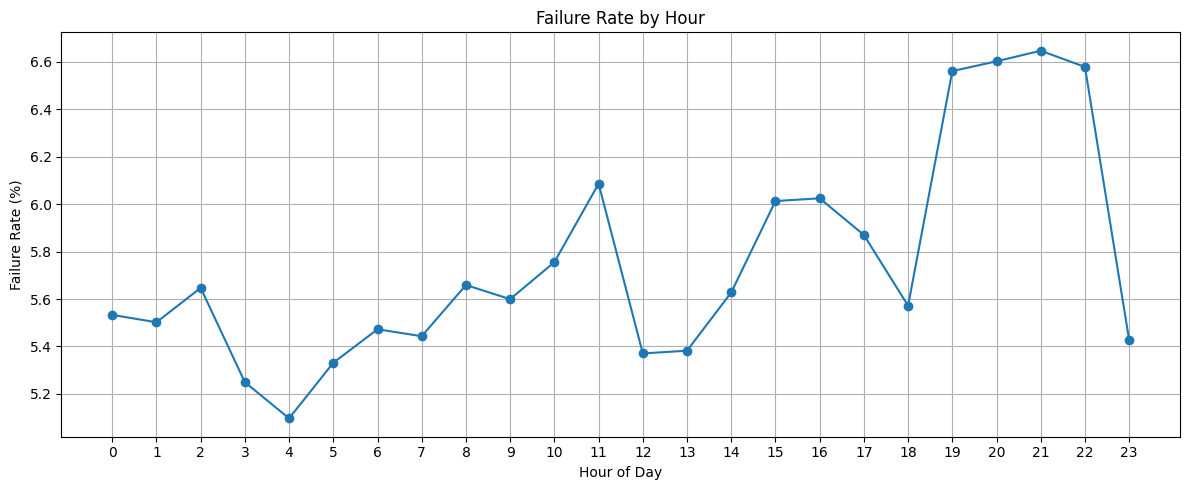

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    failure_by_hour["hour"],
    failure_by_hour["failure_rate_pct"],
    marker="o"
)

plt.title("Failure Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Failure Rate (%)")
plt.xticks(range(24))
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
stations.columns.tolist()

['station_id',
 'city',
 'zone',
 'latitude',
 'longitude',
 'location_type',
 'host_type',
 'commissioned_date',
 'decommissioned_date',
 'expansion_wave',
 'charger_generation',
 'slots_2w',
 'slots_3w',
 'inventory_target_2w',
 'inventory_target_3w',
 'monthly_rent_inr',
 'monthly_maintenance_inr',
 'grid_tariff_inr_kwh',
 'connectivity_tier',
 'firmware_version',
 'firmware_updated_date',
 'competitor_within_1_5km_since']

In [ ]:
stations = pd.read_csv("/content/hackathon_data/stations.csv")

print(stations.shape)
print(stations.columns.tolist())

(152, 22)
['station_id', 'city', 'zone', 'latitude', 'longitude', 'location_type', 'host_type', 'commissioned_date', 'decommissioned_date', 'expansion_wave', 'charger_generation', 'slots_2w', 'slots_3w', 'inventory_target_2w', 'inventory_target_3w', 'monthly_rent_inr', 'monthly_maintenance_inr', 'grid_tariff_inr_kwh', 'connectivity_tier', 'firmware_version', 'firmware_updated_date', 'competitor_within_1_5km_since']


In [ ]:
stations.columns.tolist()

['station_id',
 'city',
 'zone',
 'latitude',
 'longitude',
 'location_type',
 'host_type',
 'commissioned_date',
 'decommissioned_date',
 'expansion_wave',
 'charger_generation',
 'slots_2w',
 'slots_3w',
 'inventory_target_2w',
 'inventory_target_3w',
 'monthly_rent_inr',
 'monthly_maintenance_inr',
 'grid_tariff_inr_kwh',
 'connectivity_tier',
 'firmware_version',
 'firmware_updated_date',
 'competitor_within_1_5km_since']

In [ ]:
failure_by_location = (
    swaps_with_city.merge(
        stations[["station_id", "location_type"]],
        on="station_id",
        how="left"
    )
    .groupby("location_type")
    .agg(
        total_events=("event_id", "count"),
        failed_events=("event_type", lambda x: (x != "swap_completed").sum())
    )
    .reset_index()
)

failure_by_location["failure_rate_pct"] = (
    failure_by_location["failed_events"]
    / failure_by_location["total_events"] * 100
)

failure_by_location

,location_type,total_events,failed_events,failure_rate_pct
0,commercial_hub,1597774,97781,6.119827
1,highway_fuel_pump,329834,16852,5.109237
2,market,1246931,77752,6.235469
3,residential,382274,20827,5.448186
4,tech_park,147533,7690,5.212393
5,transit_hub,172667,10302,5.966398


In [ ]:
queue_by_location = (
    swaps_with_city.merge(
        stations[["station_id", "location_type"]],
        on="station_id",
        how="left"
    )
    .groupby("location_type")["queue_wait_min"]
    .agg(["mean", "median", "max"])
    .reset_index()
)

queue_by_location

,location_type,mean,median,max
0,commercial_hub,4.050975,3.433333,40.0
1,highway_fuel_pump,4.052550,3.450000,40.0
2,market,4.049323,3.416667,40.0
3,residential,4.042150,3.433333,40.0
4,tech_park,4.042232,3.433333,40.0
5,transit_hub,4.047648,3.433333,40.0


In [ ]:
failure_by_station.sort_values(
    "failure_rate_pct",
    ascending=False
).head(15)

,station_id,city,total_events,failed_events,failure_rate_pct
36,STN-DEL-037,Delhi NCR,30838,2799,9.076464
47,STN-DEL-048,Delhi NCR,34646,3111,8.979392
92,STN-JAI-137,Jaipur,44371,3881,8.746704
97,STN-JAI-142,Jaipur,33319,2914,8.745761
96,STN-JAI-141,Jaipur,45594,3981,8.731412
44,STN-DEL-045,Delhi NCR,32237,2811,8.719794
91,STN-JAI-136,Jaipur,29340,2555,8.708248
93,STN-JAI-138,Jaipur,48945,4242,8.666871
39,STN-DEL-040,Delhi NCR,40335,3487,8.645097
49,STN-DEL-050,Delhi NCR,47060,4053,8.612410


In [ ]:
failure_by_station.sort_values(
    "failed_events",
    ascending=False
).head(15)

,station_id,city,total_events,failed_events,failure_rate_pct
42,STN-DEL-043,Delhi NCR,49597,4271,8.611408
93,STN-JAI-138,Jaipur,48945,4242,8.666871
71,STN-HYD-072,Hyderabad,51765,4176,8.067227
49,STN-DEL-050,Delhi NCR,47060,4053,8.612410
96,STN-JAI-141,Jaipur,45594,3981,8.731412
92,STN-JAI-137,Jaipur,44371,3881,8.746704
69,STN-HYD-070,Hyderabad,49688,3768,7.583320
95,STN-JAI-140,Jaipur,44115,3733,8.461974
89,STN-JAI-134,Jaipur,42925,3612,8.414677
46,STN-DEL-047,Delhi NCR,41594,3509,8.436313


In [ ]:
stations.columns.tolist()

['station_id',
 'city',
 'zone',
 'latitude',
 'longitude',
 'location_type',
 'host_type',
 'commissioned_date',
 'decommissioned_date',
 'expansion_wave',
 'charger_generation',
 'slots_2w',
 'slots_3w',
 'inventory_target_2w',
 'inventory_target_3w',
 'monthly_rent_inr',
 'monthly_maintenance_inr',
 'grid_tariff_inr_kwh',
 'connectivity_tier',
 'firmware_version',
 'firmware_updated_date',
 'competitor_within_1_5km_since']

In [ ]:
charger_summary = (
    stations.groupby("charger_generation")
    .size()
    .reset_index(name="station_count")
)

charger_summary

,charger_generation,station_count
0,Gen1,51
1,Gen2,64
2,Gen3,37


In [ ]:
stations["charger_generation"].value_counts()

,count
charger_generation,
Gen2,64
Gen1,51
Gen3,37


In [ ]:
city_charger = pd.crosstab(
    stations["city"],
    stations["charger_generation"]
)

city_charger

charger_generation,Gen1,Gen2,Gen3
city,,,
Bengaluru,9,18,7
Delhi NCR,13,10,7
Hyderabad,13,6,7
Jaipur,10,3,5
Mumbai,2,15,5
Pune,4,12,6


In [ ]:
expansion_summary = (
    stations["expansion_wave"]
    .value_counts(dropna=False)
    .reset_index()
)

expansion_summary.columns = ["expansion_wave", "station_count"]

expansion_summary

,expansion_wave,station_count
0,Launch,92
1,Wave1_2024H2,30
2,Wave2_2025H1,30


In [ ]:
batteries_path = "/content/hackathon_data/batteries.csv"

batteries = pd.read_csv(batteries_path)

print("Batteries loaded:", batteries.shape)
batteries.head()

Batteries loaded: (6500, 13)


,battery_id,pack_type,supplier,manufacturing_lot,manufacture_date,commission_date,rated_capacity_kwh,purchase_cost_inr,initial_soh_pct,bms_firmware,retired_date,retirement_reason,current_soh_pct
0,BAT-2W-100000,2W_2.1kWh,Cellora,CE-2503,2025-01-30,2025-03-19,2.1,31018,99.9,BMS-4.1,NaN,NaN,79.5
1,BAT-2W-100001,2W_2.1kWh,Cellora,CE-2403,2024-02-27,2024-03-30,2.1,34111,99.2,BMS-4.2,NaN,NaN,79.5
2,BAT-3W-100002,3W_4.8kWh,Cellora,CE-2305,2023-04-15,2023-05-11,4.8,66521,99.5,BMS-4.1,NaN,NaN,87.0
3,BAT-2W-100003,2W_2.1kWh,Kyron,KY-2409,2024-09-28,2024-10-09,2.1,32753,99.5,BMS-4.1,2025-06-15,end_of_life,58.1
4,BAT-2W-100004,2W_2.1kWh,Kyron,KY-2407,2024-11-06,2024-11-21,2.1,31734,99.5,BMS-4.2,2025-06-15,end_of_life,60.6


In [ ]:
battery_supplier = (
    batteries["supplier"]
    .value_counts()
    .reset_index()
)

battery_supplier.columns = ["supplier", "battery_count"]

battery_supplier

,supplier,battery_count
0,Cellora,3555
1,Kyron,1638
2,Amptek,1307


In [ ]:
swaps_battery = swaps.merge(
    batteries[["battery_id", "supplier"]],
    left_on="battery_in_id",
    right_on="battery_id",
    how="left"
)

supplier_swaps = (
    swaps_battery.groupby("supplier")
    .agg(
        total_events=("event_id", "count"),
        completed_swaps=("event_type", lambda x: (x == "swap_completed").sum()),
        failed_events=("event_type", lambda x: (x != "swap_completed").sum())
    )
    .reset_index()
)

supplier_swaps["failure_rate_pct"] = (
    supplier_swaps["failed_events"]
    / supplier_swaps["total_events"] * 100
)

supplier_swaps

,supplier,total_events,completed_swaps,failed_events,failure_rate_pct
0,Amptek,800706,759354,41352,5.164442
1,Cellora,2186756,2075611,111145,5.082643
2,Kyron,861269,810844,50425,5.854733


In [ ]:
soh_swap_supplier = (
    swaps_battery.groupby("supplier")["soh_in_pct_clean"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
)

soh_swap_supplier

,supplier,count,mean,median,min,max
0,Amptek,799926,90.076697,90.2,76.2,100.0
1,Cellora,2184776,90.037045,90.2,76.1,100.0
2,Kyron,860673,81.609413,82.6,55.2,100.0


In [ ]:
lot_summary = (
    batteries["manufacturing_lot"]
    .value_counts()
    .reset_index()
)

lot_summary.columns = ["manufacturing_lot", "battery_count"]

lot_summary.head(20)

,manufacturing_lot,battery_count
0,KY-2408,500
1,KY-2409,481
2,KY-2407,480
3,CE-2404,158
4,CE-2412,152
5,CE-2401,150
6,CE-2503,150
7,CE-2307,143
8,CE-2304,142
9,CE-2409,139


In [ ]:
batteries["commission_date"] = pd.to_datetime(
    batteries["commission_date"]
)

batteries["battery_age_days"] = (
    pd.Timestamp("2025-06-30") - batteries["commission_date"]
).dt.days

batteries["battery_age_days"].describe()

,battery_age_days
count,6500.000000
mean,353.214923
std,211.581113
min,15.000000
25%,217.000000
50%,284.000000
75%,480.000000
max,852.000000


In [ ]:
battery_age_soh = batteries[
    ["battery_id", "supplier", "battery_age_days", "current_soh_pct"]
].dropna()

battery_age_soh.head()

,battery_id,supplier,battery_age_days,current_soh_pct
0,BAT-2W-100000,Cellora,103,79.5
1,BAT-2W-100001,Cellora,457,79.5
2,BAT-3W-100002,Cellora,781,87.0
3,BAT-2W-100003,Kyron,264,58.1
4,BAT-2W-100004,Kyron,221,60.6


In [ ]:
supplier_age_soh = (
    batteries.groupby("supplier")
    .agg(
        battery_count=("battery_id", "count"),
        avg_age_days=("battery_age_days", "mean"),
        avg_soh=("current_soh_pct", "mean")
    )
    .reset_index()
)

supplier_age_soh

,supplier,battery_count,avg_age_days,avg_soh
0,Amptek,1307,252.250191,81.005203
1,Cellora,3555,441.171027,80.929030
2,Kyron,1638,242.883394,63.747436


In [ ]:
support_tickets = pd.read_csv("/content/hackathon_data/support_tickets.csv")

support_tickets.shape

(44000, 12)

In [ ]:
ticket_category_summary = (
    support_tickets["category"]
    .value_counts()
    .reset_index()
)

ticket_category_summary.columns = ["category", "ticket_count"]

ticket_category_summary

,category,ticket_count
0,no_battery_available,11647
1,other,9484
2,low_range,6636
3,app_issue,5787
4,long_queue,5731
5,billing_dispute,4715


In [ ]:
tickets_with_city = support_tickets.merge(
    stations[["station_id", "city"]],
    on="station_id",
    how="left"
)

city_tickets = (
    tickets_with_city["city"]
    .value_counts()
    .reset_index()
)

city_tickets.columns = ["city", "ticket_count"]

city_tickets

,city,ticket_count
0,Delhi NCR,9907
1,Hyderabad,8594
2,Bengaluru,7187
3,Jaipur,6536
4,Pune,5032
5,Mumbai,4517


In [ ]:
station_tickets = (
    support_tickets["station_id"]
    .value_counts()
    .reset_index()
)

station_tickets.columns = ["station_id", "ticket_count"]

station_tickets.head(15)

,station_id,ticket_count
0,STN-HYD-072,689
1,STN-DEL-043,681
2,STN-JAI-138,674
3,STN-JAI-141,645
4,STN-DEL-050,639
5,STN-JAI-140,626
6,STN-HYD-070,618
7,STN-JAI-137,586
8,STN-JAI-134,584
9,STN-HYD-065,551


In [ ]:
ticket_priority = (
    support_tickets["priority"]
    .value_counts()
    .reset_index()
)

ticket_priority.columns = ["priority", "ticket_count"]

ticket_priority

,priority,ticket_count
0,medium,19884
1,low,17649
2,high,6467


In [ ]:
support_tickets.columns.tolist()

['ticket_id',
 'rider_id',
 'station_id',
 'battery_id',
 'created_ts',
 'channel',
 'category',
 'rider_comment',
 'priority',
 'resolution_status',
 'resolution_hours',
 'csat_score']

In [ ]:
ticket_resolution = (
    support_tickets["resolution_status"]
    .value_counts()
    .reset_index()
)

ticket_resolution.columns = ["resolution_status", "ticket_count"]

ticket_resolution

,resolution_status,ticket_count
0,resolved,37888
1,unresolved,5175
2,duplicate,937


In [ ]:
csat_summary = support_tickets["csat_score"].describe()

csat_summary

,csat_score
count,15129.000000
mean,3.559720
std,1.305327
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000


In [ ]:
category_csat = (
    support_tickets.groupby("category")
    .agg(
        ticket_count=("ticket_id", "count"),
        avg_csat=("csat_score", "mean")
    )
    .reset_index()
    .sort_values("avg_csat")
)

category_csat

,category,ticket_count,avg_csat
2,long_queue,5731,3.506520
3,low_range,6636,3.531183
0,app_issue,5787,3.539805
5,other,9484,3.567468
1,billing_dispute,4715,3.569136
4,no_battery_available,11647,3.602452


In [ ]:
support_tickets["resolution_hours"].describe()

,resolution_hours
count,37888.000000
mean,15.951840
std,11.004491
min,0.900000
25%,8.500000
50%,13.200000
75%,20.200000
max,155.800000


In [ ]:
city_support = (
    tickets_with_city.groupby("city")
    .agg(
        tickets=("ticket_id", "count"),
        avg_csat=("csat_score", "mean"),
        avg_resolution_hours=("resolution_hours", "mean")
    )
    .reset_index()
    .sort_values("tickets", ascending=False)
)

city_support

,city,tickets,avg_csat,avg_resolution_hours
1,Delhi NCR,9907,3.555103,16.055939
2,Hyderabad,8594,3.548298,15.838430
0,Bengaluru,7187,3.573659,15.806889
3,Jaipur,6536,3.563249,16.088471
5,Pune,5032,3.573178,16.065791
4,Mumbai,4517,3.533762,15.914914


In [ ]:
failure_by_station.columns.tolist()

['station_id', 'city', 'total_events', 'failed_events', 'failure_rate_pct']

In [ ]:
station_complaints_failure = (
    station_tickets
    .merge(
        failure_by_station[["station_id", "failure_rate_pct"]],
        on="station_id",
        how="left"
    )
    .sort_values("ticket_count", ascending=False)
)

station_complaints_failure.head(15)

,station_id,ticket_count,failure_rate_pct
0,STN-HYD-072,689,8.067227
1,STN-DEL-043,681,8.611408
2,STN-JAI-138,674,8.666871
3,STN-JAI-141,645,8.731412
4,STN-DEL-050,639,8.612410
5,STN-JAI-140,626,8.461974
6,STN-HYD-070,618,7.583320
7,STN-JAI-137,586,8.746704
8,STN-JAI-134,584,8.414677
9,STN-HYD-065,551,7.284624


In [ ]:
station_complaints_gen = (
    station_tickets
    .merge(
        stations[["station_id", "charger_generation"]],
        on="station_id",
        how="left"
    )
    .groupby("charger_generation")
    .agg(
        stations_with_tickets=("station_id", "nunique"),
        total_tickets=("ticket_count", "sum")
    )
    .reset_index()
)

station_complaints_gen

,charger_generation,stations_with_tickets,total_tickets
0,Gen1,51,21435
1,Gen2,64,15848
2,Gen3,37,4490


In [ ]:
battery_soh = batteries["current_soh_pct"].describe()

battery_soh

,current_soh_pct
count,6500.000000
mean,76.614585
std,8.824758
min,55.400000
25%,78.400000
50%,79.800000
75%,80.800000
max,88.600000


In [ ]:
supplier_soh = (
    batteries.groupby("supplier")
    .agg(
        battery_count=("battery_id", "count"),
        avg_soh=("current_soh_pct", "mean"),
        min_soh=("current_soh_pct", "min")
    )
    .reset_index()
    .sort_values("avg_soh")
)

supplier_soh

,supplier,battery_count,avg_soh,min_soh
2,Kyron,1638,63.747436,55.4
1,Cellora,3555,80.929030,77.0
0,Amptek,1307,81.005203,76.6


In [ ]:
pack_soh = (
    batteries.groupby("pack_type")
    .agg(
        battery_count=("battery_id", "count"),
        avg_soh=("current_soh_pct", "mean")
    )
    .reset_index()
    .sort_values("avg_soh")
)

pack_soh

,pack_type,battery_count,avg_soh
0,2W_2.1kWh,5518,75.088909
1,3W_4.8kWh,982,85.187576


In [ ]:
lot_soh = (
    batteries.groupby("manufacturing_lot")
    .agg(
        battery_count=("battery_id", "count"),
        avg_soh=("current_soh_pct", "mean")
    )
    .reset_index()
    .sort_values("avg_soh")
)

lot_soh.head(20)

,manufacturing_lot,battery_count,avg_soh
45,KY-2409,481,60.915177
43,KY-2407,480,60.986042
44,KY-2408,500,61.048400
20,CE-2307,143,80.598601
7,AM-2410,81,80.602469
29,CE-2404,158,80.612658
23,CE-2310,117,80.617094
30,CE-2405,127,80.636220
2,AM-2405,88,80.636364
19,CE-2306,122,80.650000


In [ ]:
low_soh = batteries[
    batteries["current_soh_pct"] < 80
].copy()

low_soh_summary = (
    low_soh.groupby("supplier")
    .agg(
        low_soh_batteries=("battery_id", "count")
    )
    .reset_index()
    .sort_values("low_soh_batteries", ascending=False)
)

low_soh_summary

,supplier,low_soh_batteries
1,Cellora,1493
2,Kyron,1461
0,Amptek,548


In [ ]:
swaps.columns.tolist()

['event_id',
 'rider_id',
 'station_id',
 'event_ts',
 'event_type',
 'attempt_seq',
 'queue_wait_sec',
 'battery_in_id',
 'battery_out_id',
 'soc_in_pct',
 'soh_in_pct',
 'soc_out_pct',
 'soh_out_pct',
 'km_since_last_swap',
 'tariff_code',
 'list_price_inr',
 'discount_inr',
 'amount_charged_inr',
 'payment_mode',
 'energy_to_recharge_kwh',
 'station_firmware',
 'sync_mode',
 'km_since_last_swap_clean',
 'soc_out_pct_clean',
 'soh_in_pct_clean',
 'soh_out_pct_clean',
 'month',
 'queue_wait_min',
 'hour']

In [ ]:
tariff_analysis = (
    swaps.groupby("tariff_code")
    .agg(
        total_events=("event_id", "count"),
        completed_swaps=("event_type", lambda x: (x == "swap_completed").sum()),
        revenue=("amount_charged_inr", "sum")
    )
    .reset_index()
)

tariff_analysis["completion_rate_pct"] = (
    tariff_analysis["completed_swaps"] /
    tariff_analysis["total_events"] * 100
)

tariff_analysis["avg_revenue_per_event"] = (
    tariff_analysis["revenue"] /
    tariff_analysis["total_events"]
)

tariff_analysis

,tariff_code,total_events,completed_swaps,revenue,completion_rate_pct,avg_revenue_per_event
0,OFFPEAK,37720,36098,2.149346e+06,95.699894,56.981601
1,PARTNER,2565478,2409841,1.487535e+08,93.933411,57.982768
2,PEAK,177879,169833,1.401990e+07,95.476700,78.817061
3,STD,1095936,1030037,6.820330e+07,93.986966,62.232918


In [ ]:
vehicle_revenue = (
    swaps_with_vehicle[
        swaps_with_vehicle["event_type"] == "swap_completed"
    ]
    .groupby("vehicle_class")
    .agg(
        completed_swaps=("event_id", "count"),
        revenue=("amount_charged_inr", "sum"),
        avg_revenue_per_swap=("amount_charged_inr", "mean")
    )
    .reset_index()
)

vehicle_revenue

,vehicle_class,completed_swaps,revenue,avg_revenue_per_swap
0,2W,3265675,1.952430e+08,59.786430
1,3W,380134,3.788301e+07,99.656978


In [ ]:
rider_events = (
    swaps.groupby("rider_id")
    .agg(
        total_events=("event_id", "count"),
        completed_swaps=("event_type", lambda x: (x == "swap_completed").sum())
    )
    .reset_index()
)

rider_events["returned"] = rider_events["completed_swaps"] > 1

rider_events.head()

,rider_id,total_events,completed_swaps,returned
0,RD-1000000,235,209,True
1,RD-1000001,165,152,True
2,RD-1000002,787,740,True
3,RD-1000003,121,117,True
4,RD-1000004,440,422,True


In [ ]:
return_rate = (
    rider_events["returned"].mean() * 100
)

print(f"Rider return rate: {return_rate:.2f}%")

Rider return rate: 99.47%


In [ ]:
rider_failure = (
    swaps.groupby("rider_id")
    .agg(
        total_events=("event_id", "count"),
        failed_events=("event_type", lambda x: (x != "swap_completed").sum()),
        avg_queue_wait_min=("queue_wait_min", "mean")
    )
    .reset_index()
)

rider_failure["failure_rate_pct"] = (
    rider_failure["failed_events"] /
    rider_failure["total_events"] * 100
)

rider_failure.describe()

,total_events,failed_events,avg_queue_wait_min,failure_rate_pct
count,19950.000000,19950.000000,19950.000000,19950.000000
mean,194.336491,11.589173,4.051769,6.710982
std,164.262678,11.077090,0.473009,5.609461
min,1.000000,0.000000,0.016667,0.000000
25%,59.000000,3.000000,3.883366,3.539823
50%,151.000000,8.000000,4.039035,5.371901
75%,291.000000,17.000000,4.198587,8.484848
max,936.000000,85.000000,14.516667,100.000000


In [ ]:
rider_experience = rider_events.merge(
    rider_failure[
        ["rider_id", "failure_rate_pct", "avg_queue_wait_min"]
    ],
    on="rider_id",
    how="left"
)

rider_experience.groupby("returned").agg(
    riders=("rider_id", "count"),
    avg_failure_rate=("failure_rate_pct", "mean"),
    avg_queue_wait=("avg_queue_wait_min", "mean")
).reset_index()

,returned,riders,avg_failure_rate,avg_queue_wait
0,False,105,13.492063,4.479788
1,True,19845,6.675103,4.049505


In [ ]:
print("Total Events:", len(swaps))
print("Completed Swaps:", (swaps["event_type"] == "swap_completed").sum())
print("Non-Completed Events:", (swaps["event_type"] != "swap_completed").sum())

completed = swaps[swaps["event_type"] == "swap_completed"]

print("Total Revenue (₹):", completed["amount_charged_inr"].sum())
print("Avg Revenue / Completed Swap (₹):", completed["amount_charged_inr"].mean())
print("Overall Failure Rate (%):",
      (swaps["event_type"] != "swap_completed").mean() * 100)

Total Events: 3877013
Completed Swaps: 3645809
Non-Completed Events: 231204
Total Revenue (₹): 233126055.54999998
Avg Revenue / Completed Swap (₹): 63.9435734428216
Overall Failure Rate (%): 5.963456919025033


In [ ]:
failure_reasons = (
    swaps[swaps["event_type"] != "swap_completed"]
    ["event_type"]
    .value_counts()
    .reset_index()
)

failure_reasons.columns = ["failure_type", "count"]

failure_reasons["percentage"] = (
    failure_reasons["count"] /
    failure_reasons["count"].sum() * 100
)

failure_reasons

,failure_type,count,percentage
0,failed_no_charged_battery,134389,58.125724
1,abandoned_queue,68533,29.641788
2,cancelled_by_rider,16712,7.228249
3,failed_system_error,11570,5.004239


In [ ]:
city_failure_summary = (
    swaps_with_city.groupby("city")
    .agg(
        total_events=("event_id", "count"),
        failed_events=("event_type",
                       lambda x: (x != "swap_completed").sum())
    )
    .reset_index()
)

city_failure_summary["failure_rate_pct"] = (
    city_failure_summary["failed_events"] /
    city_failure_summary["total_events"] * 100
)

city_failure_summary.sort_values(
    "failure_rate_pct", ascending=False
)

,city,total_events,failed_events,failure_rate_pct
3,Jaipur,487634,38268,7.847689
1,Delhi NCR,768913,56528,7.351677
2,Hyderabad,711930,47618,6.688579
5,Pune,552910,27579,4.987973
0,Bengaluru,825327,37630,4.559405
4,Mumbai,530299,23581,4.446737


In [ ]:
monthly_final = (
    swaps.groupby("month")
    .agg(
        total_events=("event_id", "count"),
        completed_swaps=("event_type",
                         lambda x: (x == "swap_completed").sum()),
        revenue=("amount_charged_inr", "sum")
    )
    .reset_index()
)

monthly_final["failure_rate_pct"] = (
    (monthly_final["total_events"] -
     monthly_final["completed_swaps"]) /
    monthly_final["total_events"] * 100
)

monthly_final

,month,total_events,completed_swaps,revenue,failure_rate_pct
0,2024-01,110348,105490,6318995.20,4.402436
1,2024-02,111531,106582,6387614.80,4.437331
2,2024-03,123900,118444,7093617.00,4.403551
3,2024-04,131818,122836,7370255.80,6.813940
4,2024-05,146278,128328,7689594.00,12.271155
5,2024-06,148888,133743,8003275.60,10.172076
6,2024-07,158688,151824,9879524.60,4.325469
7,2024-08,172295,164931,10724296.65,4.274065
8,2024-09,195885,187302,12115209.50,4.381653
9,2024-10,229901,219838,14577271.65,4.377101


In [ ]:
results = {
    "monthly_final": monthly_final,
    "failure_reasons": failure_reasons,
    "city_failure_summary": city_failure_summary,
    "tariff_analysis": tariff_analysis,
    "vehicle_revenue": vehicle_revenue,
    "supplier_soh": supplier_soh,
    "rider_experience": rider_experience
}

print("Final analysis tables prepared:", len(results))

Final analysis tables prepared: 7


In [ ]:
final_kpis = {
    "Total Events": len(swaps),
    "Completed Swaps": (swaps["event_type"] == "swap_completed").sum(),
    "Non-Completed Events": (swaps["event_type"] != "swap_completed").sum(),
    "Failure Rate %": round(
        (swaps["event_type"] != "swap_completed").mean() * 100, 2
    ),
    "Total Revenue ₹": round(
        swaps.loc[
            swaps["event_type"] == "swap_completed",
            "amount_charged_inr"
        ].sum(), 2
    ),
    "Avg Revenue / Completed Swap ₹": round(
        swaps.loc[
            swaps["event_type"] == "swap_completed",
            "amount_charged_inr"
        ].mean(), 2
    ),
    "Rider Return Rate %": round(return_rate, 2)
}

final_kpis

{'Total Events': 3877013,
 'Completed Swaps': np.int64(3645809),
 'Non-Completed Events': np.int64(231204),
 'Failure Rate %': np.float64(5.96),
 'Total Revenue ₹': np.float64(233126055.55),
 'Avg Revenue / Completed Swap ₹': np.float64(63.94),
 'Rider Return Rate %': np.float64(99.47)}

In [ ]:
failure_reasons

,failure_type,count,percentage
0,failed_no_charged_battery,134389,58.125724
1,abandoned_queue,68533,29.641788
2,cancelled_by_rider,16712,7.228249
3,failed_system_error,11570,5.004239


In [ ]:
city_failure_summary.sort_values(
    "failure_rate_pct",
    ascending=False
)

,city,total_events,failed_events,failure_rate_pct
3,Jaipur,487634,38268,7.847689
1,Delhi NCR,768913,56528,7.351677
2,Hyderabad,711930,47618,6.688579
5,Pune,552910,27579,4.987973
0,Bengaluru,825327,37630,4.559405
4,Mumbai,530299,23581,4.446737


In [ ]:
rider_experience.groupby("returned").agg(
    riders=("rider_id", "count"),
    avg_failure_rate=("failure_rate_pct", "mean"),
    avg_queue_wait=("avg_queue_wait_min", "mean")
).reset_index()

,returned,riders,avg_failure_rate,avg_queue_wait
0,False,105,13.492063,4.479788
1,True,19845,6.675103,4.049505


In [ ]:
monthly_final

,month,total_events,completed_swaps,revenue,failure_rate_pct
0,2024-01,110348,105490,6318995.20,4.402436
1,2024-02,111531,106582,6387614.80,4.437331
2,2024-03,123900,118444,7093617.00,4.403551
3,2024-04,131818,122836,7370255.80,6.813940
4,2024-05,146278,128328,7689594.00,12.271155
5,2024-06,148888,133743,8003275.60,10.172076
6,2024-07,158688,151824,9879524.60,4.325469
7,2024-08,172295,164931,10724296.65,4.274065
8,2024-09,195885,187302,12115209.50,4.381653
9,2024-10,229901,219838,14577271.65,4.377101


In [ ]:
rider_experience.groupby("returned").agg(
    riders=("rider_id", "count"),
    avg_failure_rate=("failure_rate_pct", "mean"),
    avg_queue_wait=("avg_queue_wait_min", "mean")
).reset_index()

,returned,riders,avg_failure_rate,avg_queue_wait
0,False,105,13.492063,4.479788
1,True,19845,6.675103,4.049505


In [ ]:
tariff_analysis

,tariff_code,total_events,completed_swaps,revenue,completion_rate_pct,avg_revenue_per_event
0,OFFPEAK,37720,36098,2.149346e+06,95.699894,56.981601
1,PARTNER,2565478,2409841,1.487535e+08,93.933411,57.982768
2,PEAK,177879,169833,1.401990e+07,95.476700,78.817061
3,STD,1095936,1030037,6.820330e+07,93.986966,62.232918


In [ ]:
vehicle_revenue

,vehicle_class,completed_swaps,revenue,avg_revenue_per_swap
0,2W,3265675,1.952430e+08,59.786430
1,3W,380134,3.788301e+07,99.656978


# Key Insights
## Key Insights

### 1. Network Performance
The network recorded 3.88 million swap events, with 3.65 million completed swaps and an overall non-completion rate of 5.96%.

### 2. Battery Availability
Failed swaps due to no charged battery represented 58.13% of all non-completed events, making battery availability the largest observed failure category.

### 3. Queue Abandonment
Abandoned queue events represented 29.64% of non-completed events. Together, battery availability and queue abandonment accounted for 87.77% of non-completed events.

### 4. Seasonal/Monthly Pattern
The highest observed monthly failure rate occurred in May 2024 at 12.27%, followed by June 2024 at 10.17%.

### 5. City-Level Variation
Failure rates varied across cities, with Jaipur at 7.85%, Delhi NCR at 7.35%, and Hyderabad at 6.69%.

# Recommendations

### 1. Improve Battery Availability
Monitor battery availability at high-failure stations and ensure sufficient charged batteries during peak demand periods.

### 2. Reduce Queue Abandonment
Identify stations and time periods with high queue abandonment and optimize battery replenishment and service capacity.

### 3. Focus on High-Failure Cities
Prioritize operational investigation in Jaipur, Delhi NCR and Hyderabad, where observed failure rates were relatively higher.

### 4. Monitor Seasonal Failure Spikes
Investigate the causes behind the higher failure rates observed during May-June periods and prepare additional operational capacity for similar demand periods.

### 5. Improve Station-Level Monitoring
Create station-level KPIs for failure rate, queue wait time, battery availability and customer complaints to identify problem stations early.

In [ ]:
print(monthly_final.columns.tolist())

['month', 'total_events', 'completed_swaps', 'revenue', 'failure_rate_pct']


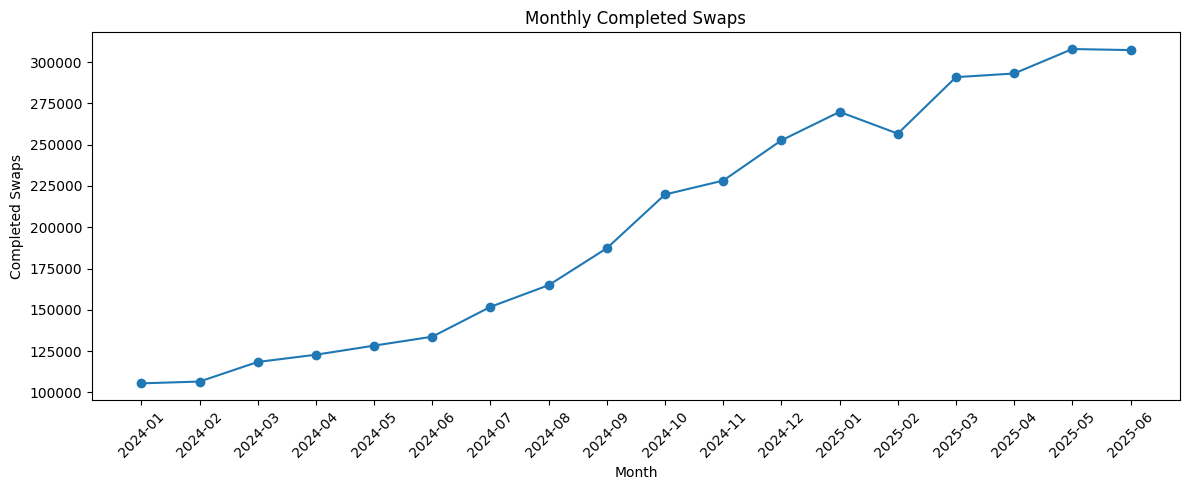

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    monthly_final["month"].astype(str),
    monthly_final["completed_swaps"],
    marker="o"
)

plt.title("Monthly Completed Swaps")
plt.xlabel("Month")
plt.ylabel("Completed Swaps")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

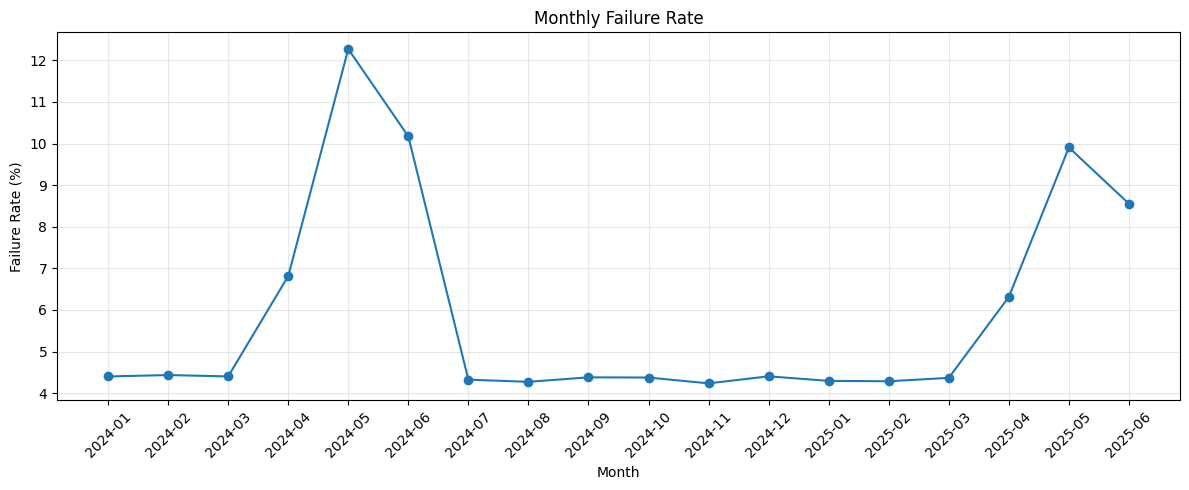

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    monthly_final["month"].astype(str),
    monthly_final["failure_rate_pct"],
    marker="o"
)

plt.title("Monthly Failure Rate")
plt.xlabel("Month")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

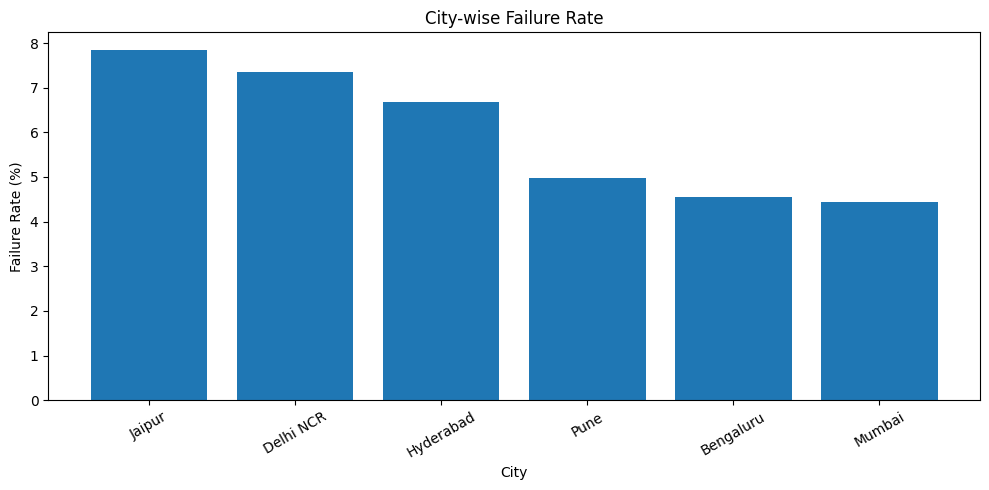

In [ ]:
import matplotlib.pyplot as plt

city_failure = (
    swaps.assign(
        failed=swaps["event_type"] != "swap_completed"
    )
    .groupby("station_id")
    .agg(
        total_events=("event_id", "count"),
        failed_events=("failed", "sum")
    )
    .reset_index()
)

city_failure = city_failure.merge(
    stations[["station_id", "city"]],
    on="station_id",
    how="left"
)

city_failure = (
    city_failure.groupby("city")
    .agg(
        total_events=("total_events", "sum"),
        failed_events=("failed_events", "sum")
    )
    .reset_index()
)

city_failure["failure_rate_pct"] = (
    city_failure["failed_events"] /
    city_failure["total_events"] * 100
)

city_failure = city_failure.sort_values(
    "failure_rate_pct", ascending=False
)

plt.figure(figsize=(10,5))
plt.bar(city_failure["city"], city_failure["failure_rate_pct"])
plt.title("City-wise Failure Rate")
plt.xlabel("City")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

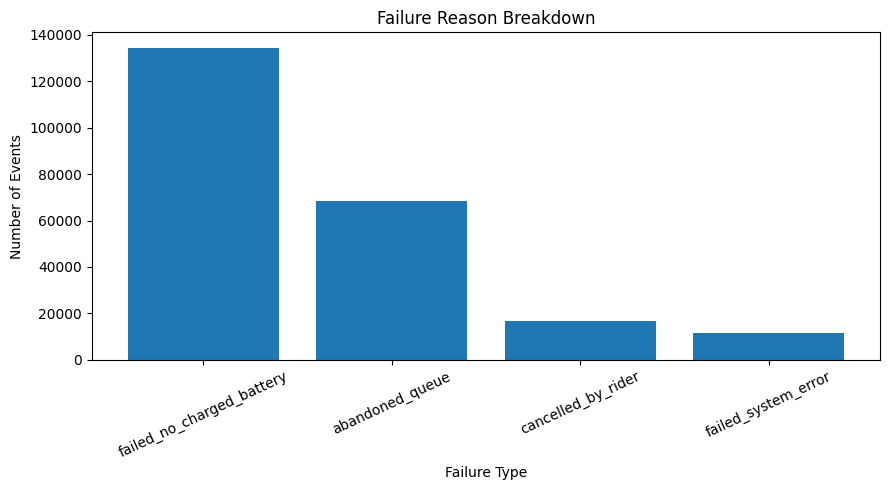

In [ ]:
failure_reason = (
    swaps[swaps["event_type"] != "swap_completed"]
    ["event_type"]
    .value_counts()
)

plt.figure(figsize=(9,5))
plt.bar(
    failure_reason.index,
    failure_reason.values
)

plt.title("Failure Reason Breakdown")
plt.xlabel("Failure Type")
plt.ylabel("Number of Events")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

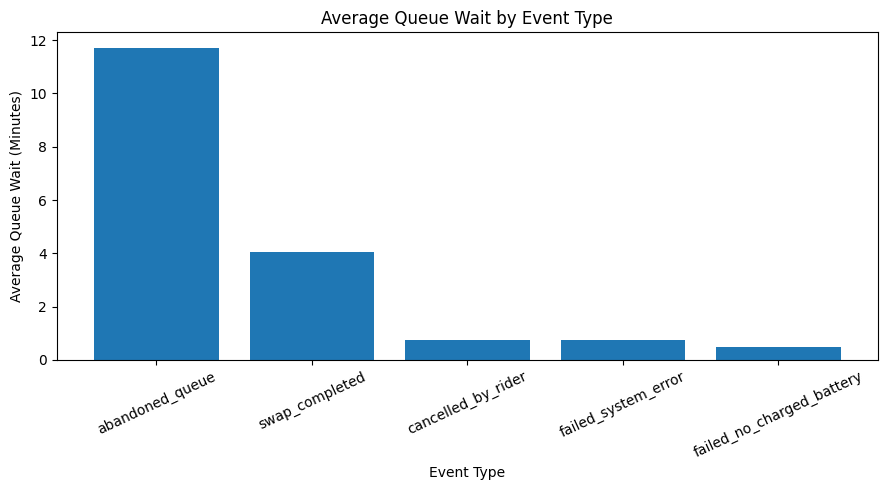

In [ ]:
queue_analysis = (
    swaps.groupby("event_type")["queue_wait_min"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))
plt.bar(
    queue_analysis.index,
    queue_analysis.values
)

plt.title("Average Queue Wait by Event Type")
plt.xlabel("Event Type")
plt.ylabel("Average Queue Wait (Minutes)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

  charger_generation  total_events  failed_events  failure_rate_pct
0               Gen1       1822034         131736          7.230161
1               Gen2       1682738          81445          4.840029
2               Gen3        372241          18023          4.841756


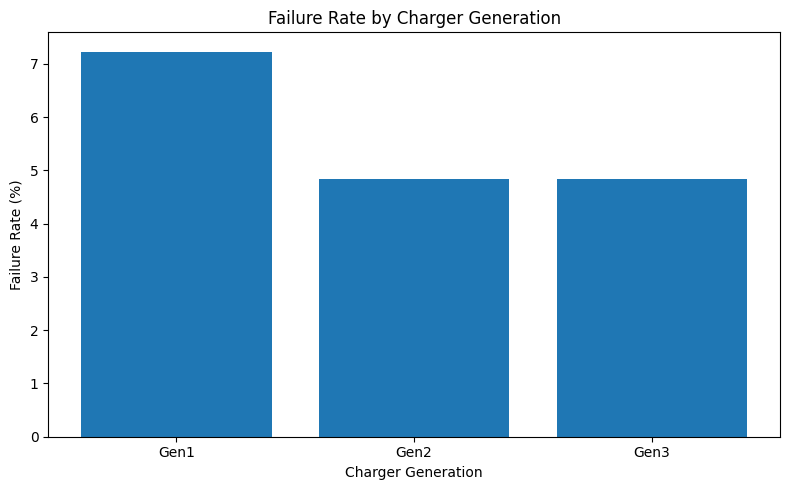

In [ ]:
charger_failure = (
    swaps.assign(
        failed=swaps["event_type"] != "swap_completed"
    )
    .merge(
        stations[["station_id", "charger_generation"]],
        on="station_id",
        how="left"
    )
    .groupby("charger_generation")
    .agg(
        total_events=("event_id", "count"),
        failed_events=("failed", "sum")
    )
    .reset_index()
)

charger_failure["failure_rate_pct"] = (
    charger_failure["failed_events"] /
    charger_failure["total_events"] * 100
)

print(charger_failure)

plt.figure(figsize=(8,5))
plt.bar(
    charger_failure["charger_generation"],
    charger_failure["failure_rate_pct"]
)

plt.title("Failure Rate by Charger Generation")
plt.xlabel("Charger Generation")
plt.ylabel("Failure Rate (%)")
plt.tight_layout()
plt.show()

# Final Analysis Charts

The final analysis includes:
1. Monthly Completed Swaps
2. Monthly Failure Rate
3. City-wise Failure Rate
4. Failure Reason Breakdown
5. Average Queue Wait by Event Type
6. Failure Rate by Charger Generation

# Final Key Findings

### Network Performance
- The dataset contains 3.88 million swap events, including 3.65 million completed swaps.
- Overall non-completion rate is approximately 5.96%.
- Completed swaps generated approximately ₹23.31 crore in revenue.
- Average revenue per completed swap is approximately ₹63.94.

### Service Failures
- Failed attempts are mainly associated with battery availability and queue abandonment.
- "Failed - No Charged Battery" represents approximately 58.13% of non-completed events.
- "Abandoned Queue" represents approximately 29.64% of non-completed events.
- Together, these two categories account for approximately 87.77% of non-completed events.

### Time Pattern
- Failure rates increased sharply during May-June 2024.
- A second increase was observed during April-June 2025.
- This indicates that operational capacity and service availability should be monitored during high-risk periods.

### Geographic Pattern
- Failure rates vary substantially across cities.
- Jaipur and Delhi NCR show higher observed failure rates than Mumbai and Bengaluru.

### Operational Focus
- Battery availability, queue management and station-level performance should be monitored closely.

# Business Recommendations

1. **Improve Battery Availability**
   - Monitor charged-battery availability at high-failure stations.
   - Rebalance battery inventory based on demand patterns.

2. **Reduce Queue Abandonment**
   - Identify stations and hours with high queue abandonment.
   - Improve battery replenishment and service capacity during peak periods.

3. **Prioritize High-Failure Locations**
   - Investigate stations with consistently high failure rates.
   - Compare their battery availability, queue time, charger generation and complaints.

4. **Prepare for High-Risk Periods**
   - Use historical monthly patterns to plan additional operational capacity during periods with higher failure rates.

5. **Create Station-Level Monitoring**
   - Track failure rate, queue wait, battery availability and customer complaints through a recurring operations dashboard.

# Analysis Limitations

- The dataset is synthetic and represents a simulated battery-swapping network.
- Observational analysis identifies patterns and associations but does not prove causation.
- Missing telemetry values were treated as missing rather than automatically converted to zero.
- Some data-quality issues were identified in the dataset, including timestamp and measurement anomalies.
- Rider retention in this analysis was operationally defined using completed swap activity and should not be interpreted as a formal long-term retention metric.

# Project Summary

This analysis evaluated the operational performance of VoltRelay Energy's simulated battery-swapping network.

The analysis covered:

- Network performance and revenue trends
- Service failure patterns
- Queue waiting and abandonment
- City and station-level performance
- Charger generation performance
- Battery and equipment characteristics
- Customer support and complaints
- Pricing and vehicle segments
- Rider repeat activity

The analysis identified battery availability, queue abandonment and geographic variation as important areas for operational investigation.

The findings can support better battery allocation, queue management, station monitoring and operational planning.